## Analysis of green development in Copenhagen

## Dependencies

### Run "!pip install -r requirements.txt" to install required libraries.

In [395]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor

## Main program

### Loading dataset

In [396]:
df = pd.read_csv("../data/trae_basis.csv")
df = df.set_index("FID")
plant_years = df.pop("planteaar")
df.insert(2, "planteaar", plant_years)
df.head(10)

/tmp/ipykernel_868396/3002090786.py:1: DtypeWarning: Columns (51,57,58,59,60,69,70,71,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/trae_basis.csv")


,uuid,id,planteaar,kategori,saerligt_trae,type,element,under_element,ny_dm_element,ny_dm_under_element,...,torso_frekvens_styning,torso_naeste_styning,torso_skaeres_ned_til,torso_bemaerkning,seneste_beskaering_aar,frekvens_beskaering,naeste_beskaering_aar,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,2021.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,2.1.1 Gadetræer,Gade- og allétræer,Allétræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,1980.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540942745348927 55.66559139825601)
trae_basis.6,9b811378-bdf6-45aa-9976-11c4c4fa08f4,86072,2018.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.549210897525631 55.685760838944354)
trae_basis.7,06c89733-e567-4111-ac60-fcd0a33324e8,704,2001.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.47405164299221 55.711393179650955)
trae_basis.8,e96b2933-d8df-4471-abd4-d64f9de40c33,94614,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Træer i bevoksninger,Træ i bevoksning,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.637429239229801 55.65761780982644)
trae_basis.9,1978d244-9902-48e0-be5e-43d202794acf,1052,2016.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.485816295327014 55.70748267524754)


### Data points and unknown data points (NaNs)

In [415]:
print(f"Data points: {len(df.index) * len(df.columns)}")
print(f"NaNs: {df.isna().sum().sum()}")

Data points: 2039730
NaNs: 41912


### Changing "Ikke registreret" to be of NaNs

In [397]:
df = df.replace("Ikke registreret", np.nan)
display(df)

,uuid,id,planteaar,kategori,saerligt_trae,type,element,under_element,ny_dm_element,ny_dm_under_element,...,torso_frekvens_styning,torso_naeste_styning,torso_skaeres_ned_til,torso_bemaerkning,seneste_beskaering_aar,frekvens_beskaering,naeste_beskaering_aar,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,2021.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,2.1.1 Gadetræer,Gade- og allétræer,Allétræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,1980.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540942745348927 55.66559139825601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.639966830590264 55.650495149618195)


### Visualising the distribution of NaNs across columns

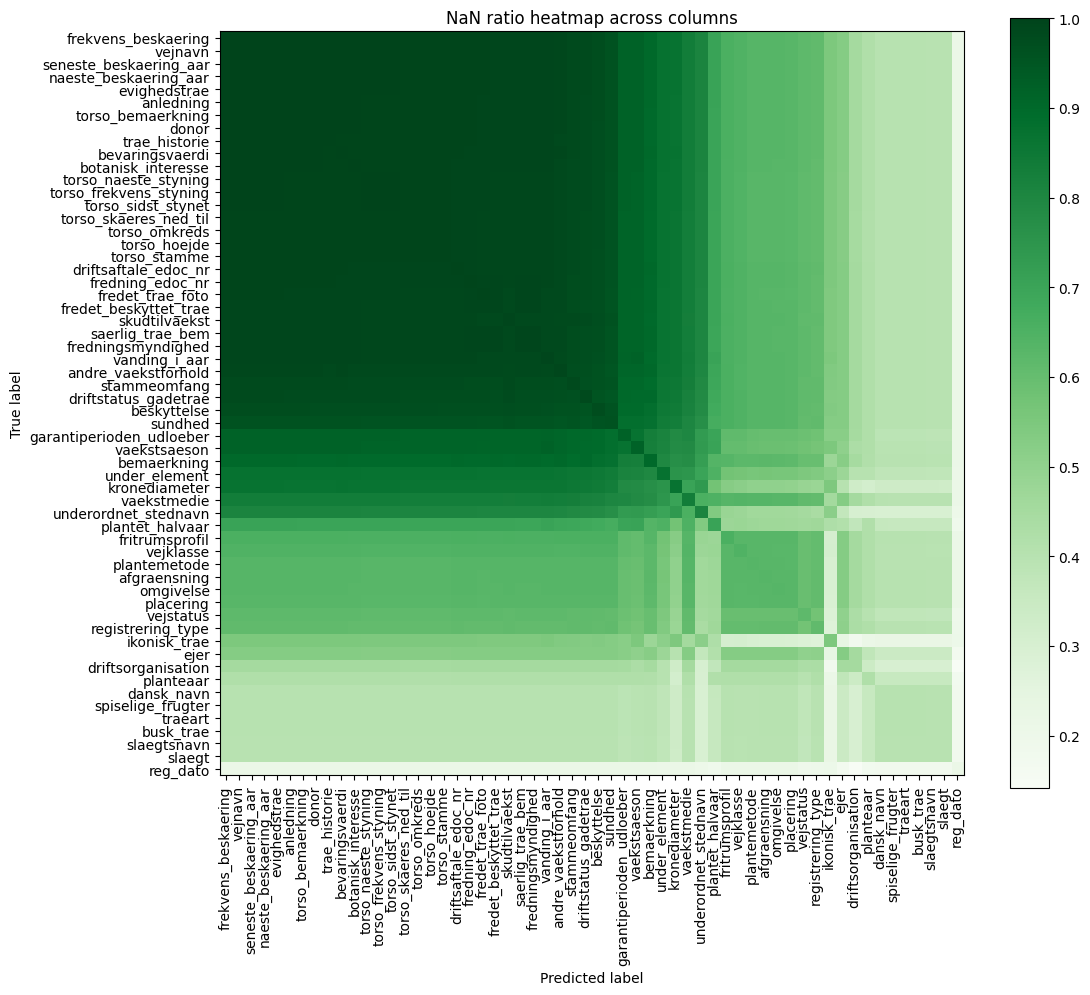

,nan_share
frekvens_beskaering,1.000000
vejnavn,1.000000
seneste_beskaering_aar,1.000000
naeste_beskaering_aar,1.000000
evighedstrae,0.999985
anledning,0.999529
torso_bemaerkning,0.999500
donor,0.999029
trae_historie,0.998735
bevaringsvaerdi,0.997838


In [398]:
nan_ratio = df.isna().mean().sort_values(ascending=False)
min_nan_share = 0.2
nan_ratio_filtered = nan_ratio[nan_ratio >= min_nan_share]

nan_mask = df[nan_ratio_filtered.index].isna().astype(int)
co_missing_share = (nan_mask.T @ nan_mask) / len(df)

fig, ax = plt.subplots(figsize=(12, 10))
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=co_missing_share.values,
    display_labels=co_missing_share.columns,
)
cm_display.plot(ax=ax, cmap="Greens", colorbar=True, include_values=False, xticks_rotation=90)
ax.set_title("NaN ratio heatmap across columns")
plt.show()

nan_ratio_filtered.to_frame("nan_share")

## Analysis of tree amount over time

### Getting trees with known plant year

In [399]:
known_plant_years = df.drop(df[pd.isna(df.loc[:, "planteaar"])].index)
display(known_plant_years)

,uuid,id,planteaar,kategori,saerligt_trae,type,element,under_element,ny_dm_element,ny_dm_under_element,...,torso_frekvens_styning,torso_naeste_styning,torso_skaeres_ned_til,torso_bemaerkning,seneste_beskaering_aar,frekvens_beskaering,naeste_beskaering_aar,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,2021.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,2.1.1 Gadetræer,Gade- og allétræer,Allétræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,1980.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540942745348927 55.66559139825601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67928,40e2da87-cf18-40cc-ad61-887209e95331,91699,2020.0,parktræ,nej,2 Træer,Park- og naturtræer,Parktræ,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.594258860893818 55.65107459300965)
trae_basis.67931,bf966919-b454-4450-a6c3-41282d1e9e9c,91723,2020.0,parktræ,nej,2 Træer,Park- og naturtræer,Parktræ,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.594424160294265 55.65097845524675)
trae_basis.67939,5e4c6e21-8b54-4c78-b221-a931ac96fae8,91880,2020.0,parktræ,nej,2 Træer,Park- og naturtræer,Parktræ,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.59605672433198 55.65239601367538)


### Plotting distribution

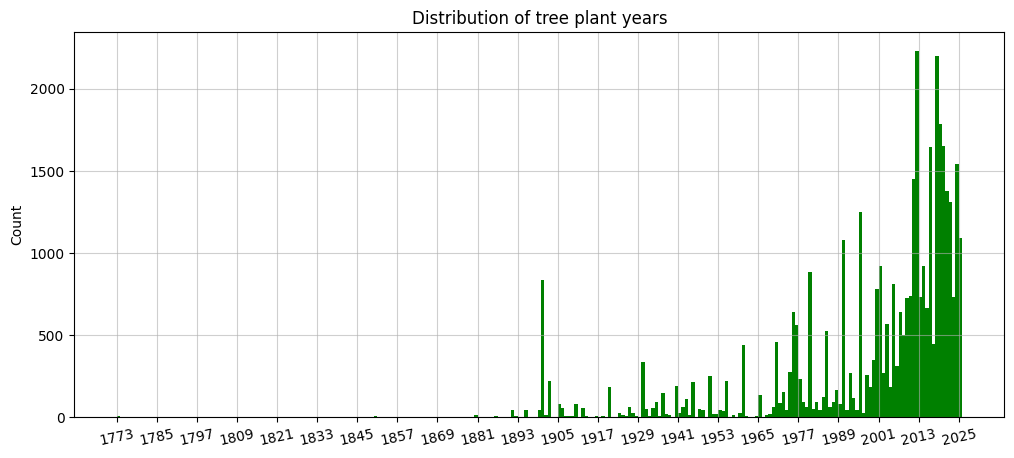

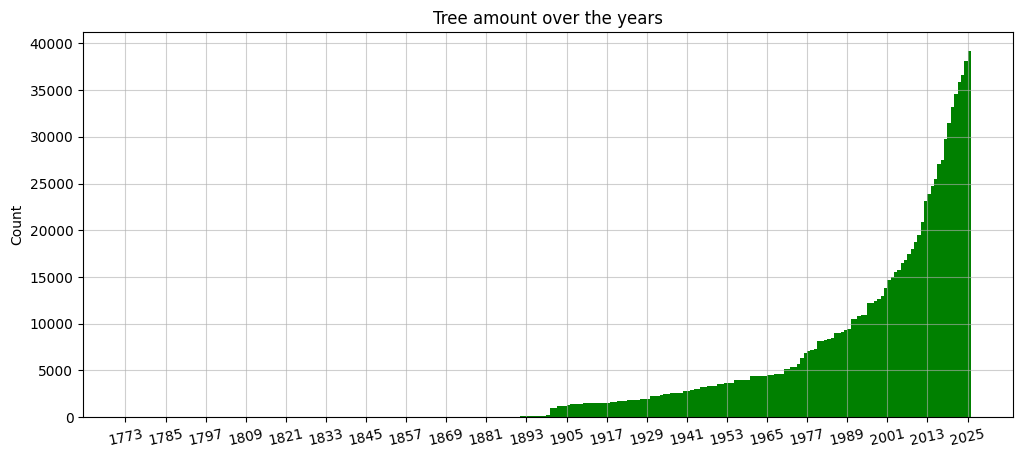

In [400]:
plant_years = known_plant_years.loc[:, "planteaar"]
plant_years.mask(plant_years > 2026, 2026, inplace=True)
oldest_tree_year = min(plant_years)
youngest_tree_year = max(plant_years)
plant_year_range = youngest_tree_year-oldest_tree_year

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green")
plt.title("Distribution of tree plant years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/dist.png")
plt.show()

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green", cumulative=True)
plt.title("Tree amount over the years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/cumu.png")
plt.show()

### Showing trees with unknown plant year

In [401]:
unknown_year_trees = df[pd.isna(df.loc[:, "planteaar"])]
display(unknown_year_trees)

,uuid,id,planteaar,kategori,saerligt_trae,type,element,under_element,ny_dm_element,ny_dm_under_element,...,torso_frekvens_styning,torso_naeste_styning,torso_skaeres_ned_til,torso_bemaerkning,seneste_beskaering_aar,frekvens_beskaering,naeste_beskaering_aar,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.8,e96b2933-d8df-4471-abd4-d64f9de40c33,94614,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Træer i bevoksninger,Træ i bevoksning,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.637429239229801 55.65761780982644)
trae_basis.16,54466184-a4f5-42de-a223-b51b3e263738,107524,NaN,parktræ,nej,2 Træer,NaN,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.612816105913323 55.65654613967322)
trae_basis.24,b2047097-b1c5-4712-ac53-661dc8edaf5e,90786,NaN,parktræ,nej,2 Træer,NaN,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.566391609568514 55.68268652388288)
trae_basis.27,e4f904f7-d246-4ea2-a169-c045f93e62ee,83011,NaN,parktræ,nej,2 Træer,NaN,NaN,Træer i bevoksninger,Træ i bevoksning,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.487251993243346 55.65164351000413)
trae_basis.28,14275f15-9130-474c-974b-8a3c1babc159,107527,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.616683759742166 55.65697473398831)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,NaN,parktræ,nej,2 Træer,2.3 Parktræer,NaN,Park- og naturtræer,Parktræ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.639966830590264 55.650495149618195)


## Preprocessing and model training

### Removing features with too many unknown values

In [402]:
df = df.dropna(axis=1, thresh=round(len(df.index) / 2))

target_col = "planteaar"
non_features = ["uuid", "id", "wkb_geometry", target_col]
features = df.columns.drop(non_features, errors="ignore")

display(df)

,uuid,id,planteaar,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,...,underordnet_byrumstype,stednavn,luftfyldt_topbaerelag_plast,driftsorganisation,driftsorganisation_vanding,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,2021.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Allétræ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2022-02-22T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,1980.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540942745348927 55.66559139825601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,NaN,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,...,Klassisk park,Kastrup Fort,False,NaN,"Udliciteret til MS Toftegaard, Amager, Valby mm",NaN,2023-08-15T10:15:15.213,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,NaN,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Bella_Bella_284,...,Klassisk park,Flagpladsen,False,NaN,"Udliciteret til MS Toftegaard, Amager, Valby mm",NaN,2023-08-15T10:15:15.213,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,NaN,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,...,Klassisk park,Kastrup Fort,False,NaN,"Udliciteret til MS Toftegaard, Amager, Valby mm",NaN,2023-08-15T10:15:15.213,nej,nej,POINT (12.639966830590264 55.650495149618195)


### Unique feature overview

In [403]:
for feature in features:
    print(f"{feature}: {len(df[feature].unique())}")

kategori: 4
saerligt_trae: 2
type: 2
element: 10
ny_dm_element: 9
ny_dm_under_element: 13
arbsted_tekst_id: 279
driftsplan_navn: 102
traeart: 577
dansk_navn: 468
slaegt: 123
slaegtsnavn: 112
busk_trae: 3
spiselige_frugter: 5
bydelsnavn: 11
lokaludvalg: 13
byrumstype: 7
underordnet_byrumstype: 14
stednavn: 534
luftfyldt_topbaerelag_plast: 2
driftsorganisation: 8
driftsorganisation_vanding: 8
reg_dato: 8536
opdateret_dato: 1116
er_risikotrae: 6
er_flagermusetrae: 2


### Data splitting

In [404]:
X_pred_full = df[pd.isna(df.loc[:, target_col])]
X_pred = X_pred_full.drop(non_features, axis=1)
X_pred.replace(np.nan, "Ikke registreret", inplace=True)
df = df.drop(X_pred.index)

y = pd.to_numeric(df.loc[:, target_col], errors="coerce")
X = df.drop(non_features, axis=1)

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_features:
    X[col] = X[col].astype(str)

valid_idx = y.notna()
X = X.loc[valid_idx]
y = y.loc[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)
print("Training data:")
display(X_train)
display(y_train)
print("Test data:")
display(X_test)
display(y_test)
print("Prediction data:")
display(X_pred)

Training data:


,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,driftsplan_navn,traeart,dansk_navn,...,byrumstype,underordnet_byrumstype,stednavn,luftfyldt_topbaerelag_plast,driftsorganisation,driftsorganisation_vanding,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.35983,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_2457,Gadetræer Indre by,Tilia europaea,Park-Lind,...,Gader og pladser,Gade med grønt,Grønningen,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, City og Østerbro",2003-04-02T00:00:00,2022-05-30T16:38:59.623,nej,nej
trae_basis.63940,parktræ,nej,2 Træer,Træer i bevoksninger,Træer i bevoksninger,Træ i bevoksning,KMC_KMC_3210,KMC,nan,nan,...,Natur,Naturområde,Selinevej,False,nan,"Udliciteret til MS Toftegaard, Amager, Valby mm",2023-01-03T13:59:33.827,2023-08-15T10:15:15.213,nej,nej
trae_basis.37850,parktræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Allétræ,Vestr_Vestr_3035,Vestre Kirkegård,Tilia cordata,Småbladet lind,...,Kirkegårde,Kirkegårde,Vestre Kirkegård,False,nan,"Udliciteret til MS Toftegaard, Amager, Valby mm",2024-09-11T16:01:11.296,nan,nej,nej
trae_basis.52601,parktræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Småpa_Brygg_663,Småparker Østerbro,Metasequoia glyptostroboides,Vandgran,...,Gader og pladser,Grøn plads,Sankt Kjelds Plads,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, City og Østerbro",2019-01-29T09:53:29.999,2022-03-09T17:15:16.581,nej,nej
trae_basis.34205,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_2457,Gadetræer Indre by,Tilia europaea,Park-Lind,...,Gader og pladser,Gade med grønt,Frederiksborggade,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, City og Østerbro",2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.9892,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Fælle_Fælle_205,Fælledparken,Quercus robur,Stilk-eg,...,Parker,Klassisk park,Fælledparken,False,nan,KTF - Fælledparken,nan,2024-04-03T17:08:08.163,nej,nej
trae_basis.19781,parktræ,nej,2 Træer,Park- og naturtræer,Private træer,Privat træ,nan,Bispebjerg Kirkegård,Malus sieboldii 'Hesse',Japansk prydæble,...,Kirkegårde,Kirkegårde,Bispebjerg Kirkegård,False,KTF - Bynatur og Renhold,KTF - bydækkende drift,2024-09-11T15:19:56.126,2025-03-19T12:30:42.522,nej,nej
trae_basis.64506,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Søstj_1A_3444,Søstjernen,nan,nan,...,Parker,Klassisk park,Søstjernen,False,nan,"Udliciteret til MS Toftegaard, Amager, Valby mm",2012-04-26T14:41:25,2023-08-15T10:15:15.213,nej,nej


FID
trae_basis.35983    1906.0
trae_basis.63940    2018.0
trae_basis.37850    2016.0
trae_basis.52601    2019.0
trae_basis.34205    1988.0
                     ...  
trae_basis.9892     2012.0
trae_basis.19781    2020.0
trae_basis.64506    2012.0
trae_basis.1641     2000.0
trae_basis.27299    1999.0
Name: planteaar, Length: 31390, dtype: float64

Test data:


,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,driftsplan_navn,traeart,dansk_navn,...,byrumstype,underordnet_byrumstype,stednavn,luftfyldt_topbaerelag_plast,driftsorganisation,driftsorganisation_vanding,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.61726,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_2456,Gadetræer Amager Øst,Acer pseudoplatanus,Ahorn,...,Gader og pladser,Gade med grønt,Amager Strandvej,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, Amager, Valby mm",2011-07-01T00:00:00,2023-08-08T14:52:12.737,nej,nej
trae_basis.61805,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_2455,Gadetræer Amager Vest,Alnus spaethii,"Alnus spaethii, ikke navngivet på dansk",...,Gader og pladser,Gade med grønt,Ørestads Blvd.,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, Amager, Valby mm",2013-12-03T11:20:20,2023-08-08T14:52:12.737,nej,nej
trae_basis.15737,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Småpa_Mimer_2890,Småparker Nørrebro,nan,nan,...,Parker,Klassisk park,Mimersparken,False,KTF - Bynatur og Renhold,KTF - bydækkende drift,2012-06-22T11:54:48,2022-03-21T10:56:31.959,nej,nej
trae_basis.34815,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_2458,Gadetræer Østerbro,Tilia europaea,Park-Lind,...,Gader og pladser,Gade med grønt,Kvarteret ved Skt. Kjelds Plads,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, City og Østerbro",2016-04-11T14:28:52.615,2022-05-30T16:38:59.623,nej,nej
trae_basis.60806,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3387,Gadetræer Valby,Platanus hybr. acerifolia,Platan,...,Gader og pladser,Gade med grønt,Gammel Køge Landevej,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, Amager, Valby mm",2008-01-22T00:00:00,2023-08-08T14:52:12.737,nej,nej
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.59136,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3387,Gadetræer Valby,Tilia sp.,Lind,...,Gader og pladser,Gade med grønt,Gammel Køge Landevej,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, Amager, Valby mm",2011-07-01T00:00:00,2023-08-08T14:52:12.737,nej,nej
trae_basis.43902,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3438,Gadetræer Bispebjerg,Tilia platyphyllos,Storbladet lind,...,Gader og pladser,Grøn plads,Hulgårds Plads,False,Udliciteret til CARDEA,Udliciteret til CARDEA,1999-12-30T00:00:00,2022-10-21T12:42:57.018,nej,nej
trae_basis.42014,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3387,Gadetræer Valby,nan,nan,...,Gader og pladser,Gade med grønt,Gade i Valby,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, Amager, Valby mm",2022-02-11T00:00:00,2026-02-18T13:24:17.145,nej,nej


FID
trae_basis.61726    1990.0
trae_basis.61805    2013.0
trae_basis.15737    2012.0
trae_basis.34815    1990.0
trae_basis.60806    2008.0
                     ...  
trae_basis.59136    1980.0
trae_basis.43902    1947.0
trae_basis.42014    2022.0
trae_basis.19025    2023.0
trae_basis.44616    2016.0
Name: planteaar, Length: 7848, dtype: float64

Prediction data:


,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,driftsplan_navn,traeart,dansk_navn,...,byrumstype,underordnet_byrumstype,stednavn,luftfyldt_topbaerelag_plast,driftsorganisation,driftsorganisation_vanding,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.8,parktræ,nej,2 Træer,2.3 Parktræer,Træer i bevoksninger,Træ i bevoksning,Amage_1B_3450,Amager Strandpark,Ikke registreret,Ikke registreret,...,Natur,Naturområde,Amager Strandpark,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2016-10-05T07:26:17.979,2026-03-06T14:24:53.27,nej,nej
trae_basis.16,parktræ,nej,2 Træer,Ikke registreret,Park- og naturtræer,Parktræ,Småpa_Sundb_196,Småparker Sundbyøster,Ikke registreret,Ikke registreret,...,Småarealer,Rekreativt småareal,Kirkegårdsvej,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2024-09-11T15:29:57.793,2025-03-31T13:35:24.113,nej,nej
trae_basis.24,parktræ,nej,2 Træer,Ikke registreret,Park- og naturtræer,Parktræ,Ørste_Ørste_144,Ørstedsparken,Ikke registreret,Ikke registreret,...,Parker,Klassisk park,Ørstedsparken,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, City og Østerbro",2020-10-07T16:29:04.148,2023-03-07T08:28:55.288,nej,nej
trae_basis.27,parktræ,nej,2 Træer,Ikke registreret,Træer i bevoksninger,Træ i bevoksning,Viger_Viger_2250,Vigerslevparken,Aesculus sp.,Hestekastanie,...,Parker,Klassisk park,Vigerslevparken,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2017-02-13T13:27:49.964,2023-08-15T10:15:15.213,nej,nej
trae_basis.28,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Sundb_Sundb_3037,Sundby Kirkegård,Ikke registreret,Ikke registreret,...,Kirkegårde,Kirkegårde,Sundby Kirkegård,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2024-09-11T15:29:57.793,Ikke registreret,nej,nej
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,Ikke registreret,Ikke registreret,...,Parker,Klassisk park,Kastrup Fort,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej
trae_basis.67988,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Bella_Bella_284,Bellahøjmarken_Cirkuspladsen,Ikke registreret,Ikke registreret,...,Parker,Klassisk park,Flagpladsen,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej
trae_basis.67989,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,Ikke registreret,Ikke registreret,...,Parker,Klassisk park,Kastrup Fort,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej


### Training and evaluation on test set

Learning rate set to 0.032773
0:	learn: 29.4027640	test: 29.7416141	best: 29.7416141 (0)	total: 89.9ms	remaining: 7m 29s
1:	learn: 28.9534655	test: 29.2787321	best: 29.2787321 (1)	total: 134ms	remaining: 5m 33s
2:	learn: 28.5193944	test: 28.8337366	best: 28.8337366 (2)	total: 171ms	remaining: 4m 44s
3:	learn: 28.1090812	test: 28.4114165	best: 28.4114165 (3)	total: 212ms	remaining: 4m 25s
4:	learn: 27.7124298	test: 28.0038862	best: 28.0038862 (4)	total: 261ms	remaining: 4m 20s
5:	learn: 27.3396278	test: 27.6203027	best: 27.6203027 (5)	total: 301ms	remaining: 4m 10s
6:	learn: 26.9785421	test: 27.2500954	best: 27.2500954 (6)	total: 347ms	remaining: 4m 7s
7:	learn: 26.6499467	test: 26.9125388	best: 26.9125388 (7)	total: 394ms	remaining: 4m 6s
8:	learn: 26.3287383	test: 26.5854117	best: 26.5854117 (8)	total: 436ms	remaining: 4m 1s
9:	learn: 26.0199211	test: 26.2637815	best: 26.2637815 (9)	total: 488ms	remaining: 4m 3s
10:	learn: 25.7163143	test: 25.9592715	best: 25.9592715 (10)	total: 532ms

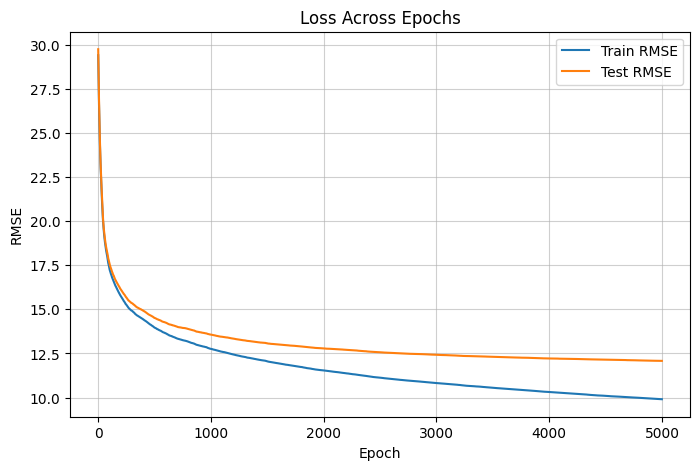

MAE: 5.71 years
RMSE: 12.08 years


In [405]:
model = CatBoostRegressor(
    num_trees=5000,
    loss_function="RMSE",
    verbose=True,
    random_seed=42,
    allow_writing_files=False,
    thread_count=-1,
    cat_features=cat_features,
    early_stopping_rounds=30,
    eval_metric="RMSE",
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
evals_result = model.get_evals_result()
train_loss = evals_result["learn"]["RMSE"]
test_loss = evals_result["validation"]["RMSE"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Train RMSE")
plt.plot(test_loss, label="Test RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Loss Across Epochs")
plt.legend()
plt.grid(alpha=0.6)
plt.show()

print(f"MAE: {mae:.2f} years")
print(f"RMSE: {rmse:.2f} years")

### Running model on NaN plant years and getting complete dataset

In [406]:
X_pred_model = X_pred
for col in cat_features:
    if col in X_pred_model.columns:
        X_pred_model[col] = X_pred_model[col].astype(str)

y_pred = np.rint(model.predict(X_pred_model)).astype(int)
X_pred_with_target = X_pred_full.replace(np.nan, "Ikke registreret")
X_pred_with_target[target_col] = y_pred
print("Predictions:")
display(X_pred_with_target)

df_base = df.drop(index=X_pred_with_target.index, errors="ignore")
df = pd.concat([df_base, X_pred_with_target], axis=0)

index_num = pd.to_numeric(
    df.index.to_series().str.extract(r"(\d+)$", expand=False),
    errors="coerce",
)
df = df.loc[index_num.sort_values(kind="stable").index]
print("Complete dataset")
display(df)

Predictions:


,uuid,id,planteaar,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,...,underordnet_byrumstype,stednavn,luftfyldt_topbaerelag_plast,driftsorganisation,driftsorganisation_vanding,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.8,e96b2933-d8df-4471-abd4-d64f9de40c33,94614,2021,parktræ,nej,2 Træer,2.3 Parktræer,Træer i bevoksninger,Træ i bevoksning,Amage_1B_3450,...,Naturområde,Amager Strandpark,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2016-10-05T07:26:17.979,2026-03-06T14:24:53.27,nej,nej,POINT (12.637429239229801 55.65761780982644)
trae_basis.16,54466184-a4f5-42de-a223-b51b3e263738,107524,2020,parktræ,nej,2 Træer,Ikke registreret,Park- og naturtræer,Parktræ,Småpa_Sundb_196,...,Rekreativt småareal,Kirkegårdsvej,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2024-09-11T15:29:57.793,2025-03-31T13:35:24.113,nej,nej,POINT (12.612816105913323 55.65654613967322)
trae_basis.24,b2047097-b1c5-4712-ac53-661dc8edaf5e,90786,2012,parktræ,nej,2 Træer,Ikke registreret,Park- og naturtræer,Parktræ,Ørste_Ørste_144,...,Klassisk park,Ørstedsparken,False,KTF - Bynatur og Renhold,"Udliciteret til MS Toftegaard, City og Østerbro",2020-10-07T16:29:04.148,2023-03-07T08:28:55.288,nej,nej,POINT (12.566391609568514 55.68268652388288)
trae_basis.27,e4f904f7-d246-4ea2-a169-c045f93e62ee,83011,2002,parktræ,nej,2 Træer,Ikke registreret,Træer i bevoksninger,Træ i bevoksning,Viger_Viger_2250,...,Klassisk park,Vigerslevparken,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2017-02-13T13:27:49.964,2023-08-15T10:15:15.213,nej,nej,POINT (12.487251993243346 55.65164351000413)
trae_basis.28,14275f15-9130-474c-974b-8a3c1babc159,107527,2019,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Sundb_Sundb_3037,...,Kirkegårde,Sundby Kirkegård,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",2024-09-11T15:29:57.793,Ikke registreret,nej,nej,POINT (12.616683759742166 55.65697473398831)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,2019,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,...,Klassisk park,Kastrup Fort,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,2022,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Bella_Bella_284,...,Klassisk park,Flagpladsen,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,2019,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,...,Klassisk park,Kastrup Fort,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej,POINT (12.639966830590264 55.650495149618195)


Complete dataset


,uuid,id,planteaar,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,...,underordnet_byrumstype,stednavn,luftfyldt_topbaerelag_plast,driftsorganisation,driftsorganisation_vanding,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,2021.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Allétræ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2022-02-22T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,1931.0,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,1980.0,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3421,...,Gade med grønt,Gade på Vesterbro,False,Udliciteret til Idverde,Udliciteret til Idverde,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540942745348927 55.66559139825601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,2019.0,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,...,Klassisk park,Kastrup Fort,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,2022.0,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Bella_Bella_284,...,Klassisk park,Flagpladsen,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,2019.0,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,...,Klassisk park,Kastrup Fort,False,Ikke registreret,"Udliciteret til MS Toftegaard, Amager, Valby mm",Ikke registreret,2023-08-15T10:15:15.213,nej,nej,POINT (12.639966830590264 55.650495149618195)


### New plant year distribution

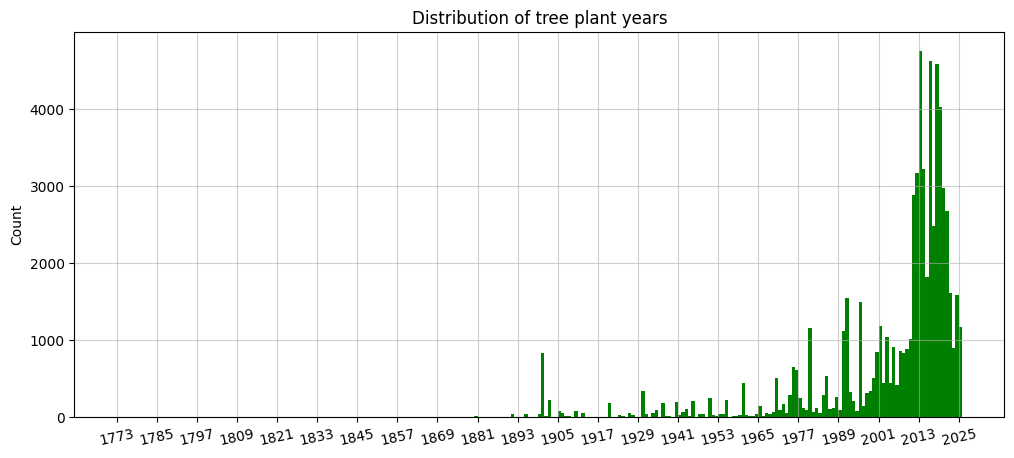

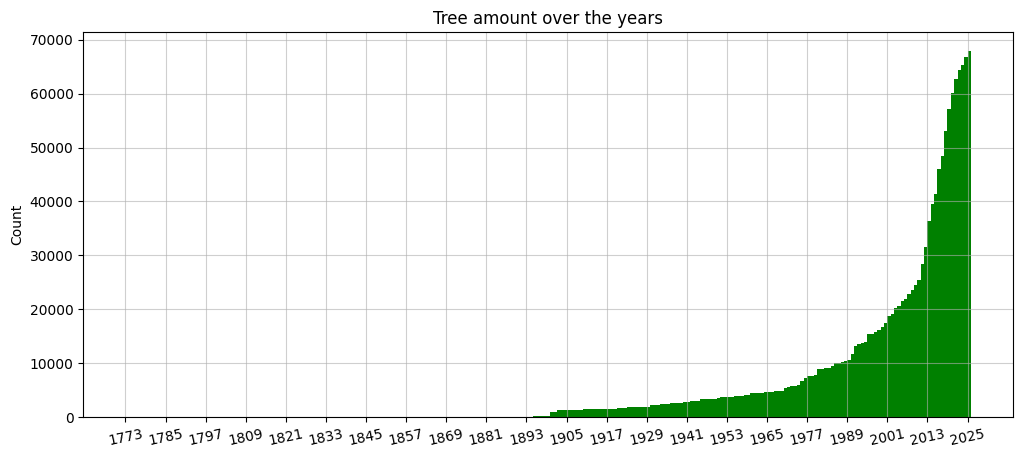

In [407]:
plant_years = df.loc[:, "planteaar"]
plant_years.mask(plant_years > 2026, 2026, inplace=True)
oldest_tree_year = min(plant_years)
youngest_tree_year = max(plant_years)
plant_year_range = youngest_tree_year-oldest_tree_year

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green")
plt.title("Distribution of tree plant years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/full_dist.png")
plt.show()

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green", cumulative=True)
plt.title("Tree amount over the years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/full_cumu.png")
plt.show()

### Saving new dataset

In [408]:
df.to_csv("../data/trae_basis_predicted.csv")